# WORC Datasets: Voxel Spacing & Matrix Dimension Analysis

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import SimpleITK as sitk

REPO_ROOT = Path(".").resolve()
META_DIR = REPO_ROOT / "metadata"
META_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "scripts"))
from build_fmcib_full_lesion_csvs import (
    DATASETS,
    WORC_ROOT,
    discover_lesion_masks,
    resolve_image_path,
)

In [2]:
def collect_dataset_rows(dataset: str) -> list[dict]:
    ds_root = WORC_ROOT / dataset
    if not ds_root.exists():
        return []

    patient_dirs = sorted(p for p in ds_root.iterdir() if p.is_dir())
    seen_images: set[Path] = set()
    rows: list[dict] = []

    for patient_dir in patient_dirs:
        patient_id = patient_dir.name
        lesions = discover_lesion_masks(dataset, patient_dir)

        for lesion_id, _mask_path, _seg_source in lesions:
            image_path = resolve_image_path(patient_dir, lesion_id).resolve()
            if image_path in seen_images:
                continue
            seen_images.add(image_path)

            image = sitk.ReadImage(str(image_path))
            sx, sy, sz = image.GetSpacing()
            size_x, size_y, size_z = image.GetSize()

            try:
                rel_path = image_path.relative_to(REPO_ROOT).as_posix()
            except ValueError:
                rel_path = image_path.as_posix()

            rows.append({
                "dataset": dataset,
                "patient_id": patient_id,
                "image_path": rel_path,
                "spacing_x_mm": float(sx),
                "spacing_y_mm": float(sy),
                "spacing_z_mm": float(sz),
                "size_x": int(size_x),
                "size_y": int(size_y),
                "size_z": int(size_z),
                "voxel_volume_mm3": float(sx * sy * sz),
            })

    return rows

all_rows = []
for ds in DATASETS:
    all_rows.extend(collect_dataset_rows(ds))

order = {name: i for i, name in enumerate(DATASETS)}
df = pd.DataFrame(all_rows)
if not df.empty:
    df = df.sort_values(
        by=["dataset", "patient_id"],
        key=lambda col: col.map(order) if col.name == "dataset" else col,
    ).reset_index(drop=True)
    df.to_csv(META_DIR / "worc_original_spacing.csv", index=False)

df.head()

,dataset,patient_id,image_path,spacing_x_mm,spacing_y_mm,spacing_z_mm,size_x,size_y,size_z,voxel_volume_mm3
0,Lipo,Lipo-001,data/worc/Lipo/Lipo-001/image.nii.gz,0.703125,0.703125,7.499999,256,224,33,3.707885
1,Lipo,Lipo-002,data/worc/Lipo/Lipo-002/image.nii.gz,0.742200,0.742200,6.599998,512,512,47,3.635681
2,Lipo,Lipo-003,data/worc/Lipo/Lipo-003/image.nii.gz,0.729167,0.729167,6.600006,576,576,40,3.509118
3,Lipo,Lipo-004,data/worc/Lipo/Lipo-004/image.nii.gz,0.585938,0.585938,5.500000,512,512,21,1.888275
4,Lipo,Lipo-005,data/worc/Lipo/Lipo-005/image.nii.gz,0.296296,0.296296,3.840001,640,640,45,0.337119


In [3]:
summary_rows = []
for dataset, g in df.groupby("dataset", sort=False):
    in_plane_spacing = pd.concat([g["spacing_x_mm"], g["spacing_y_mm"]])
    summary_rows.append({
        "Dataset": dataset,
        "Scans": len(g),
        "In-Plane Spacing [mm] (Med [Min-Max])": (
            f"{in_plane_spacing.median():.2f} [{in_plane_spacing.min():.2f} - {in_plane_spacing.max():.2f}]"
        ),
        "Slice Thickness [mm] (Med [Min-Max])": (
            f"{g['spacing_z_mm'].median():.2f} [{g['spacing_z_mm'].min():.2f} - {g['spacing_z_mm'].max():.2f}]"
        ),
        "In-Plane Size [px] (Med [Min-Max])": (
            f"{g['size_x'].median():.0f}x{g['size_y'].median():.0f} [{g['size_x'].min():.0f}-{g['size_x'].max():.0f}]"
        ),
        "Num Slices Z (Med [Min-Max])": (
            f"{g['size_z'].median():.0f} [{g['size_z'].min():.0f} - {g['size_z'].max():.0f}]"
        ),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(META_DIR / "worc_spacing_dimension_summary.csv", index=False)
summary_df

,Dataset,Scans,In-Plane Spacing [mm] (Med [Min-Max]),Slice Thickness [mm] (Med [Min-Max]),In-Plane Size [px] (Med [Min-Max]),Num Slices Z (Med [Min-Max])
0,Lipo,115,0.71 [0.23 - 1.37],5.50 [1.00 - 12.00],512x512 [220-1120],33 [15 - 69]
1,Desmoid,203,0.68 [0.23 - 1.76],5.00 [1.00 - 20.00],512x448 [204-1120],30 [13 - 176]
2,Liver,186,0.82 [0.64 - 1.64],7.70 [1.00 - 11.00],512x512 [256-560],29 [20 - 69]
3,GIST,247,0.77 [0.56 - 1.00],3.00 [0.62 - 8.10],512x512 [512-648],127 [41 - 513]
4,CRLM,77,0.74 [0.57 - 0.90],5.00 [1.00 - 22.50],512x512 [512-576],118 [35 - 549]
5,Melanoma,103,0.67 [0.54 - 0.98],1.20 [0.60 - 4.00],512x512 [512-512],240 [83 - 495]


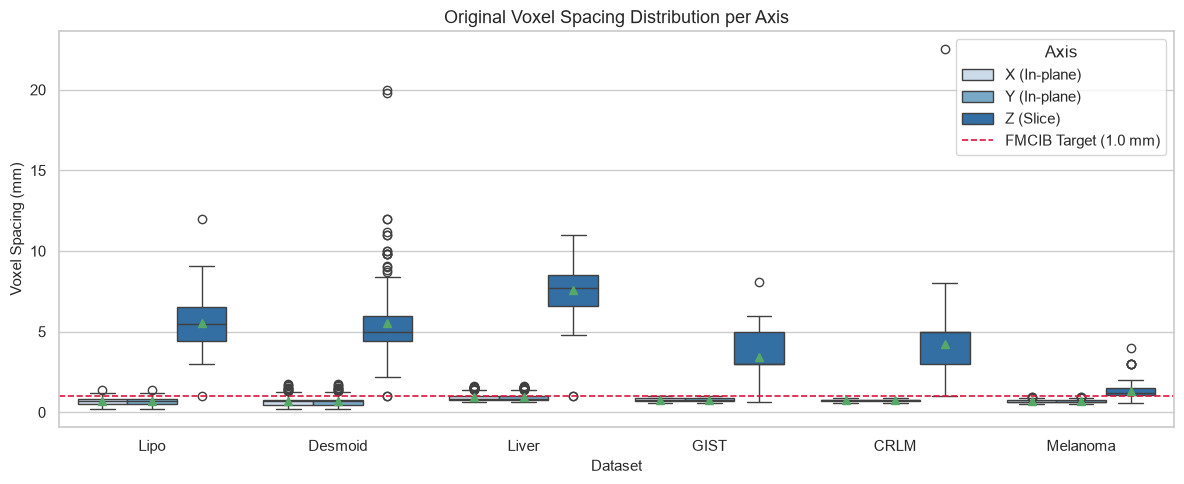

In [4]:
sns.set_theme(style="whitegrid")
active_order = [d for d in DATASETS if d in df["dataset"].unique()]

spacing_df = df.melt(
    id_vars=["dataset", "patient_id"],
    value_vars=["spacing_x_mm", "spacing_y_mm", "spacing_z_mm"],
    var_name="axis",
    value_name="spacing_mm",
)
spacing_df["axis"] = spacing_df["axis"].map({
    "spacing_x_mm": "X (In-plane)",
    "spacing_y_mm": "Y (In-plane)",
    "spacing_z_mm": "Z (Slice)",
})

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=spacing_df,
    x="dataset",
    y="spacing_mm",
    hue="axis",
    order=active_order,
    palette="Blues",
    showmeans=True,
)
ax.axhline(1.0, color="crimson", linestyle="--", linewidth=1.2, label="FMCIB Target (1.0 mm)")
ax.set_title("Original Voxel Spacing Distribution per Axis", fontsize=13)
ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("Voxel Spacing (mm)", fontsize=11)
ax.legend(title="Axis", loc="upper right")
plt.tight_layout()
plt.savefig(META_DIR / "worc_spacing_distribution.png", dpi=300)
plt.show()

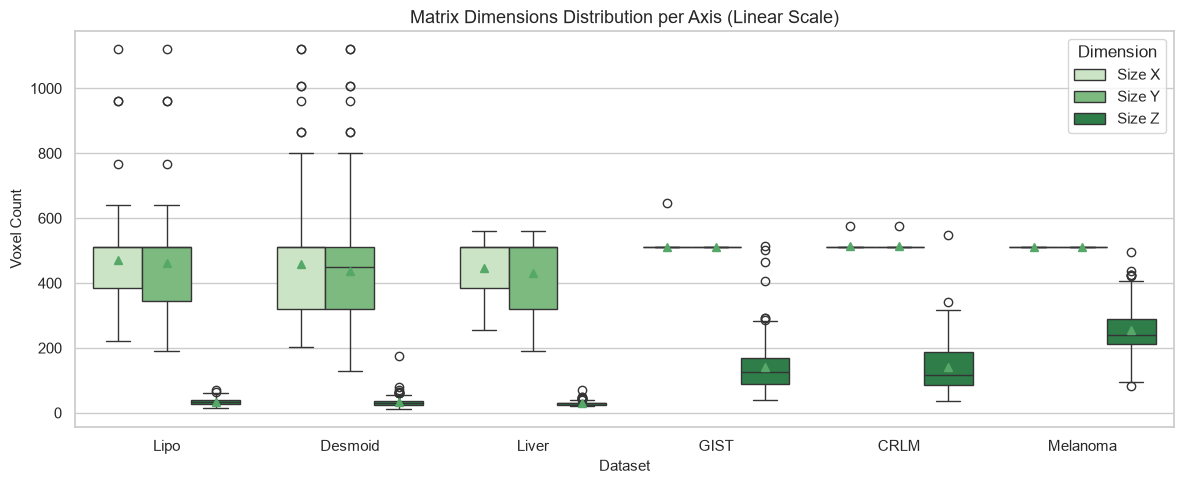

In [6]:
dim_df = df.melt(
    id_vars=["dataset", "patient_id"],
    value_vars=["size_x", "size_y", "size_z"],
    var_name="axis",
    value_name="size_voxels",
)
dim_df["axis"] = dim_df["axis"].map({
    "size_x": "Size X",
    "size_y": "Size Y",
    "size_z": "Size Z",
})

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=dim_df,
    x="dataset",
    y="size_voxels",
    hue="axis",
    order=active_order,
    palette="Greens",
    showmeans=True,
)
ax.set_title("Matrix Dimensions Distribution per Axis (Linear Scale)", fontsize=13)
ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("Voxel Count", fontsize=11)
ax.legend(title="Dimension", loc="upper right")
plt.tight_layout()
plt.savefig(META_DIR / "worc_dimensions_distribution.png", dpi=300)
plt.show()